In [20]:
%load_ext autoreload
%autoreload 2

from nn_helpers import MoogStokesNN
from mcmc_pipeline import run_stage_raw, postprocess_stage_result, postprocess_mcmc_run_file
from mcmc import retrieve_spectrum_preproc
import matplotlib.pyplot as plt
from IPython.display import Image, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
basename = "Spectrum_TWA8A.nspec"
data_path = "data/science/ClassIII-sources-spectra"

In [22]:
testdata, meta = retrieve_spectrum_preproc(
    basename,
    data_path=data_path,
    regions_override=[0, 1, 2, 3, 4, 5, 6],
    return_metadata=True,
)

print(meta)

[Nyquist sampling] Factor applied: 1. Old SNR = 105.88610166741441
[Nyquist sampling] Factor applied: 1. New SNR = 105.88610166741441
{'basename': 'Spectrum_TWA8A.nspec', 'regions': [0, 1, 2, 3, 4, 5, 6], 'n_regions': 7, 'shifts': array([11.496, 14.526, 13.51 , 14.477, 16.501, 14.498, 14.422]), 'renormalization': array([0.98, 0.99, 0.99, 0.99, 0.99, 1.  , 1.  ]), 'masks': {}, 'nyquist_bin': 1, 'kernel': None, 'resolution': None, 'abs_path': '/Users/christianflores/Documents/GitHub/moogstokes-nn/data/science/ClassIII-sources-spectra/Spectrum_TWA8A.nspec'}


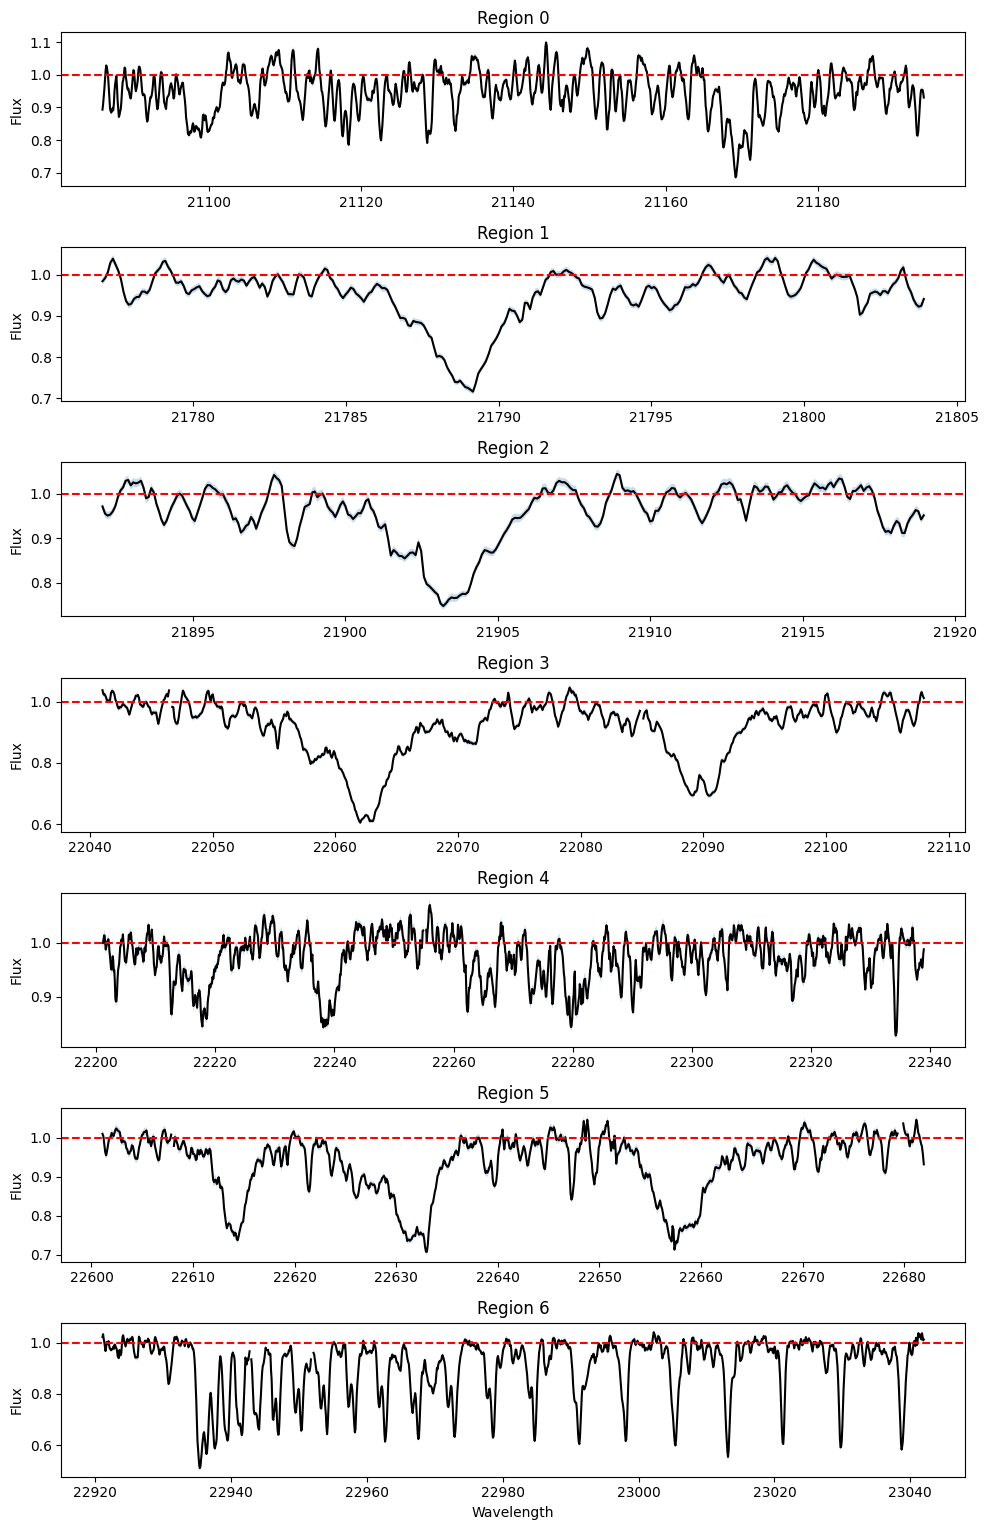

In [23]:
fig, axes = plt.subplots(len(testdata.regions), 1, figsize=(10, 2.2 * len(testdata.regions)))

if len(testdata.regions) == 1:
    axes = [axes]

for ax, r in zip(axes, testdata.regions):
    x, y, yerr = testdata.get_region(r)
    ax.plot(x, y, color="black")
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.25)
    ax.set_title(f"Region {r}")
    ax.set_ylabel("Flux")
    ax.axhline(1,color='r',linestyle='--')

axes[-1].set_xlabel("Wavelength")
plt.tight_layout()
plt.show()

In [24]:
moognn = MoogStokesNN(nn_models_dir="data/", regions=range(7))

In [6]:
stage1_out = run_stage_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    regions=[0, 1, 2, 3, 4, 5, 6],
    fixed_params={},                 # all 5 parameters free
    stage_label="all regions",
    nwalkers=64,
    nsteps=2000,
    scale_discard=1000,
    scale_thin=5,
    mcmc_runs_dir="mcmc_runs",
    save_mcmc_run_file=True,
)


[Nyquist sampling] Factor applied: 1. Old SNR = 70.4529656964564
[Nyquist sampling] Factor applied: 1. New SNR = 70.4529656964564


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [01:41<00:00,  5.88it/s]


[yerr rescaled] Factor applied: 1.4033888134911654. Total scaling so far: 1.4033888134911654


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [01:54<00:00,  5.23it/s]


4.297986724644199
MCMC run file: /Users/christianflores/Documents/GitHub/moogstokes-nn/mcmc_runs/Spectrum_HIP12635_all regions_reg0-1-2-3-4-5-6_allfree_20260707_153714_mcmc_run.npz
Summary CSV: /Users/christianflores/Documents/GitHub/moogstokes-nn/mcmc_runs/mcmc_summary_flexible.csv


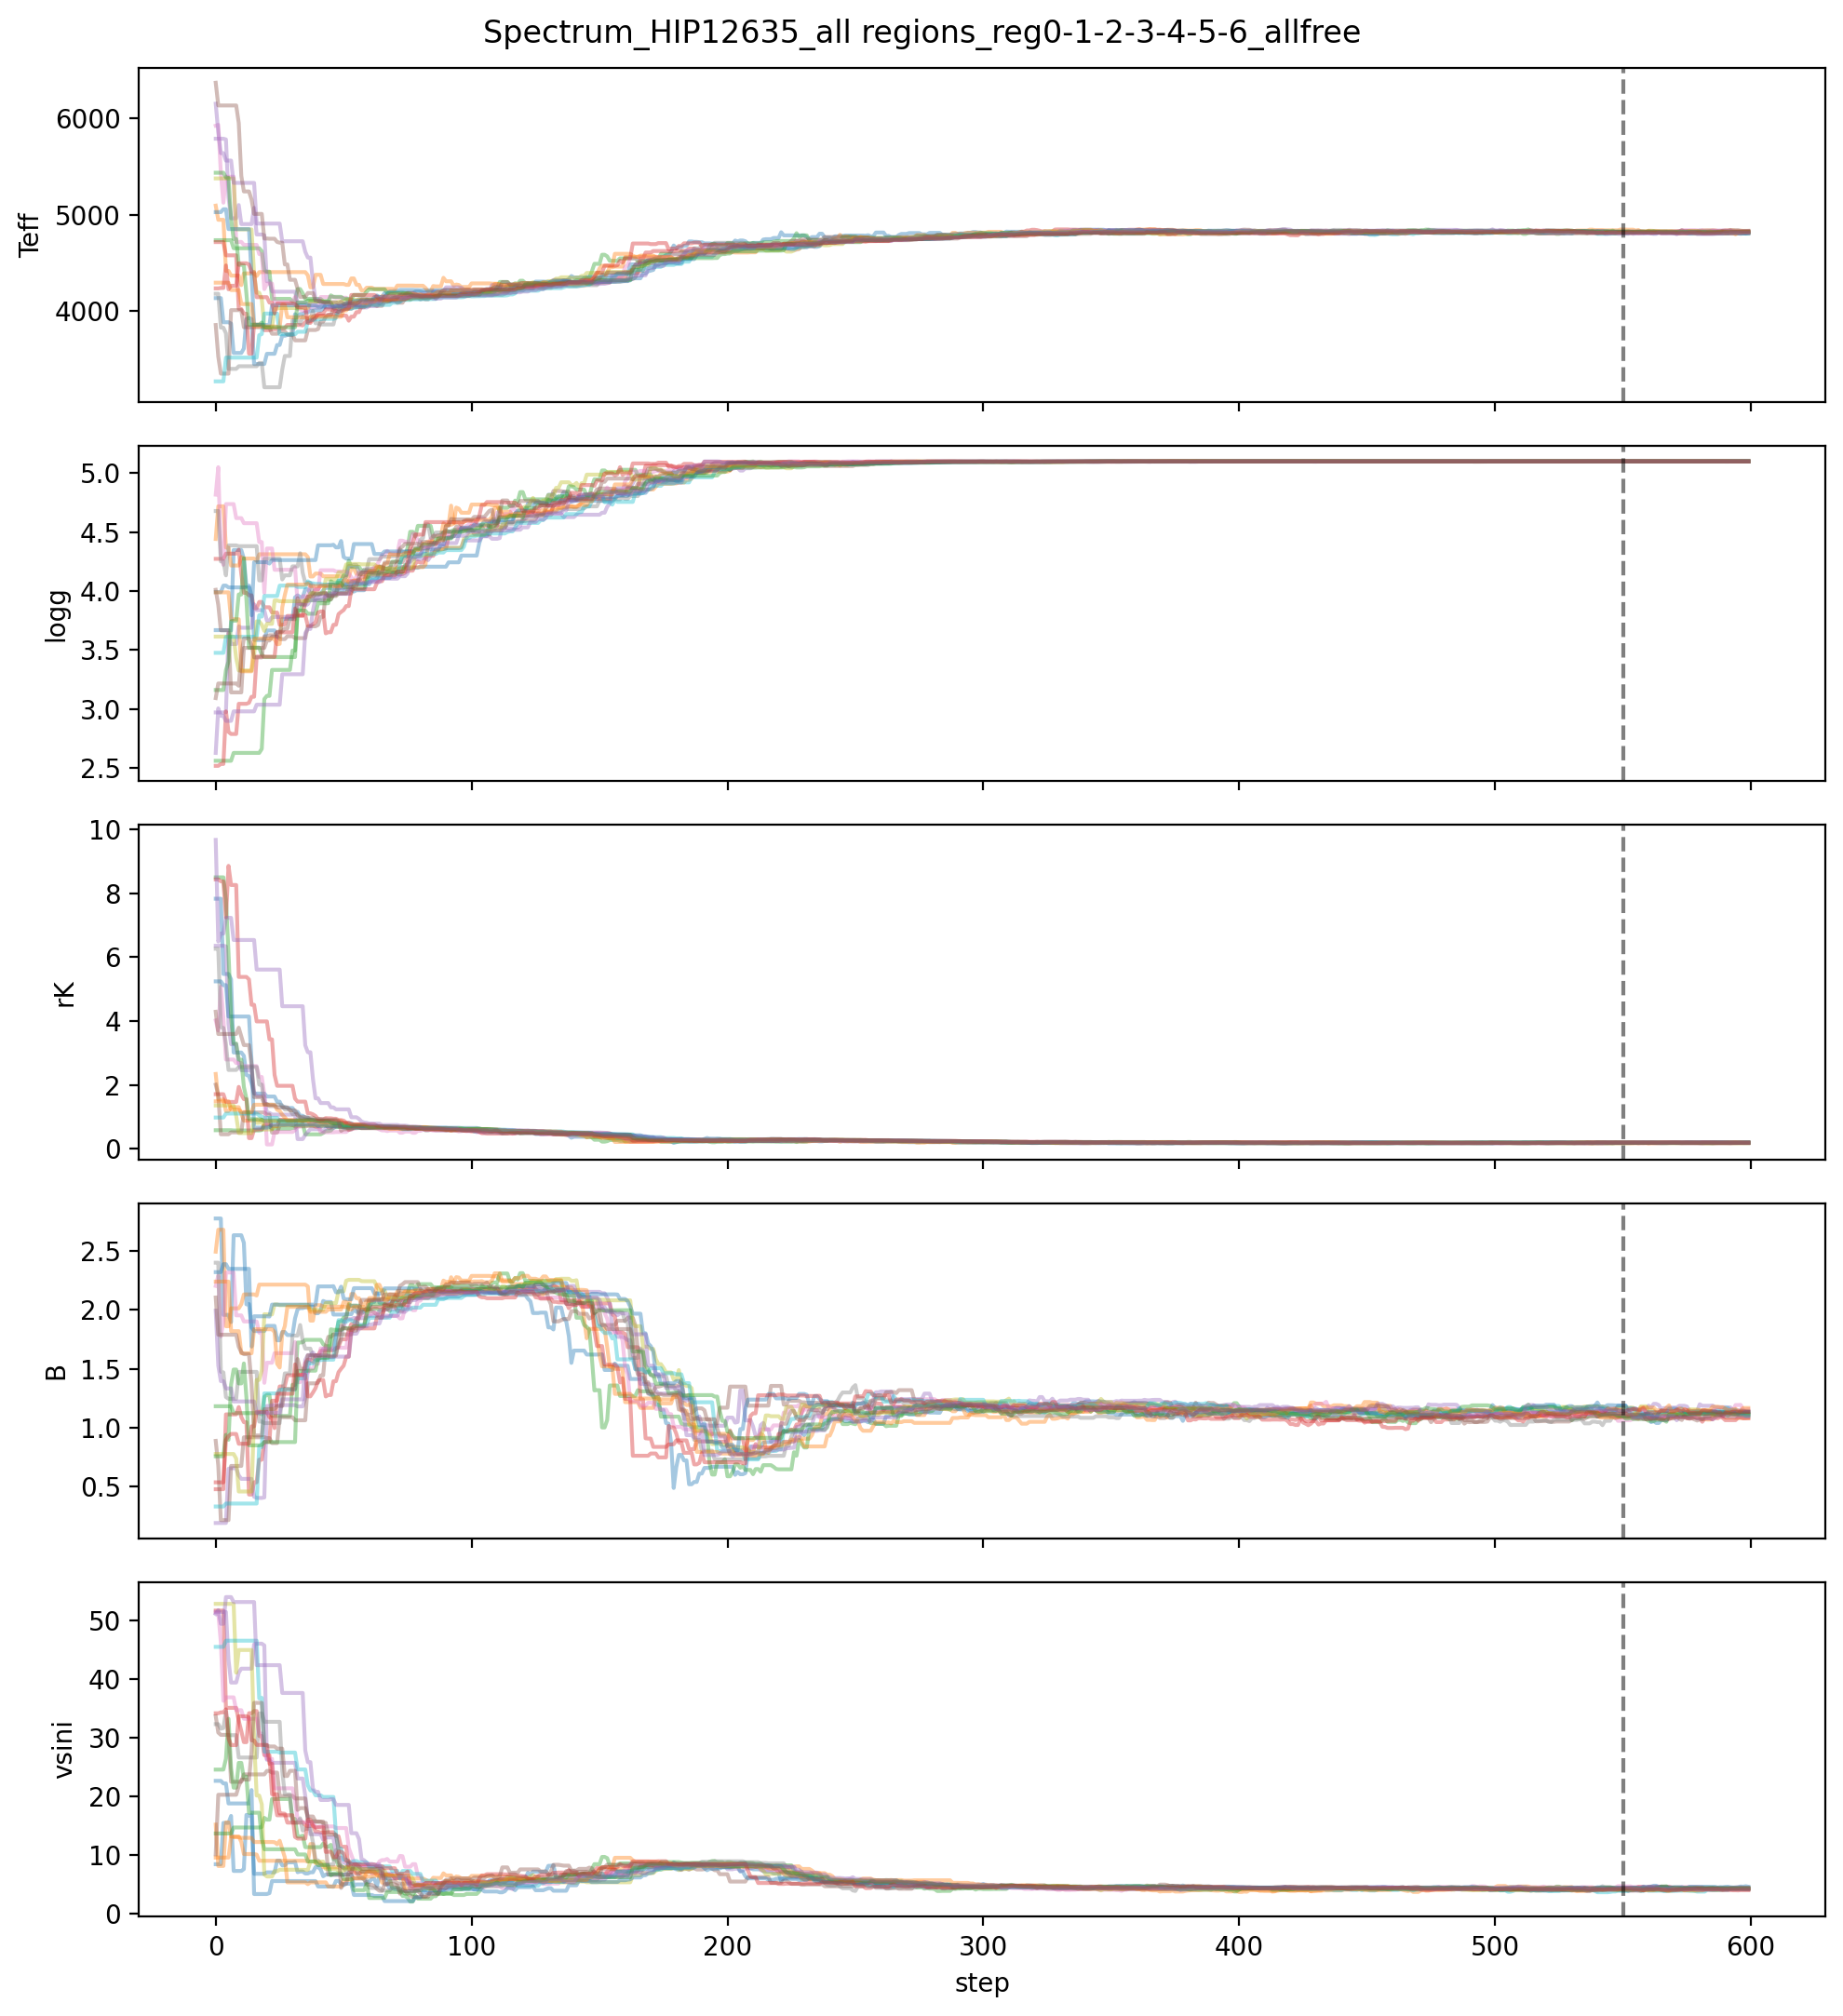

In [10]:
out1 = postprocess_stage_result(
    stage1_out,
    moognn=moognn,
    data_path=data_path,
    discard=1000,
    thin=5,
    save_fits=False,
    mcmc_runs_dir="mcmc_runs",
    figures_dir="figures",
    best_percentile=50,
    uncertainty_percentiles=(16, 84),
)

vsini_stage1 = out1["values"]["vsini"]
print(vsini_stage1)
print("MCMC run file:", out1["mcmc_run_file"])
print("Summary CSV:", out1["summary_csv"])

display(Image(out1["trace_plot"]))


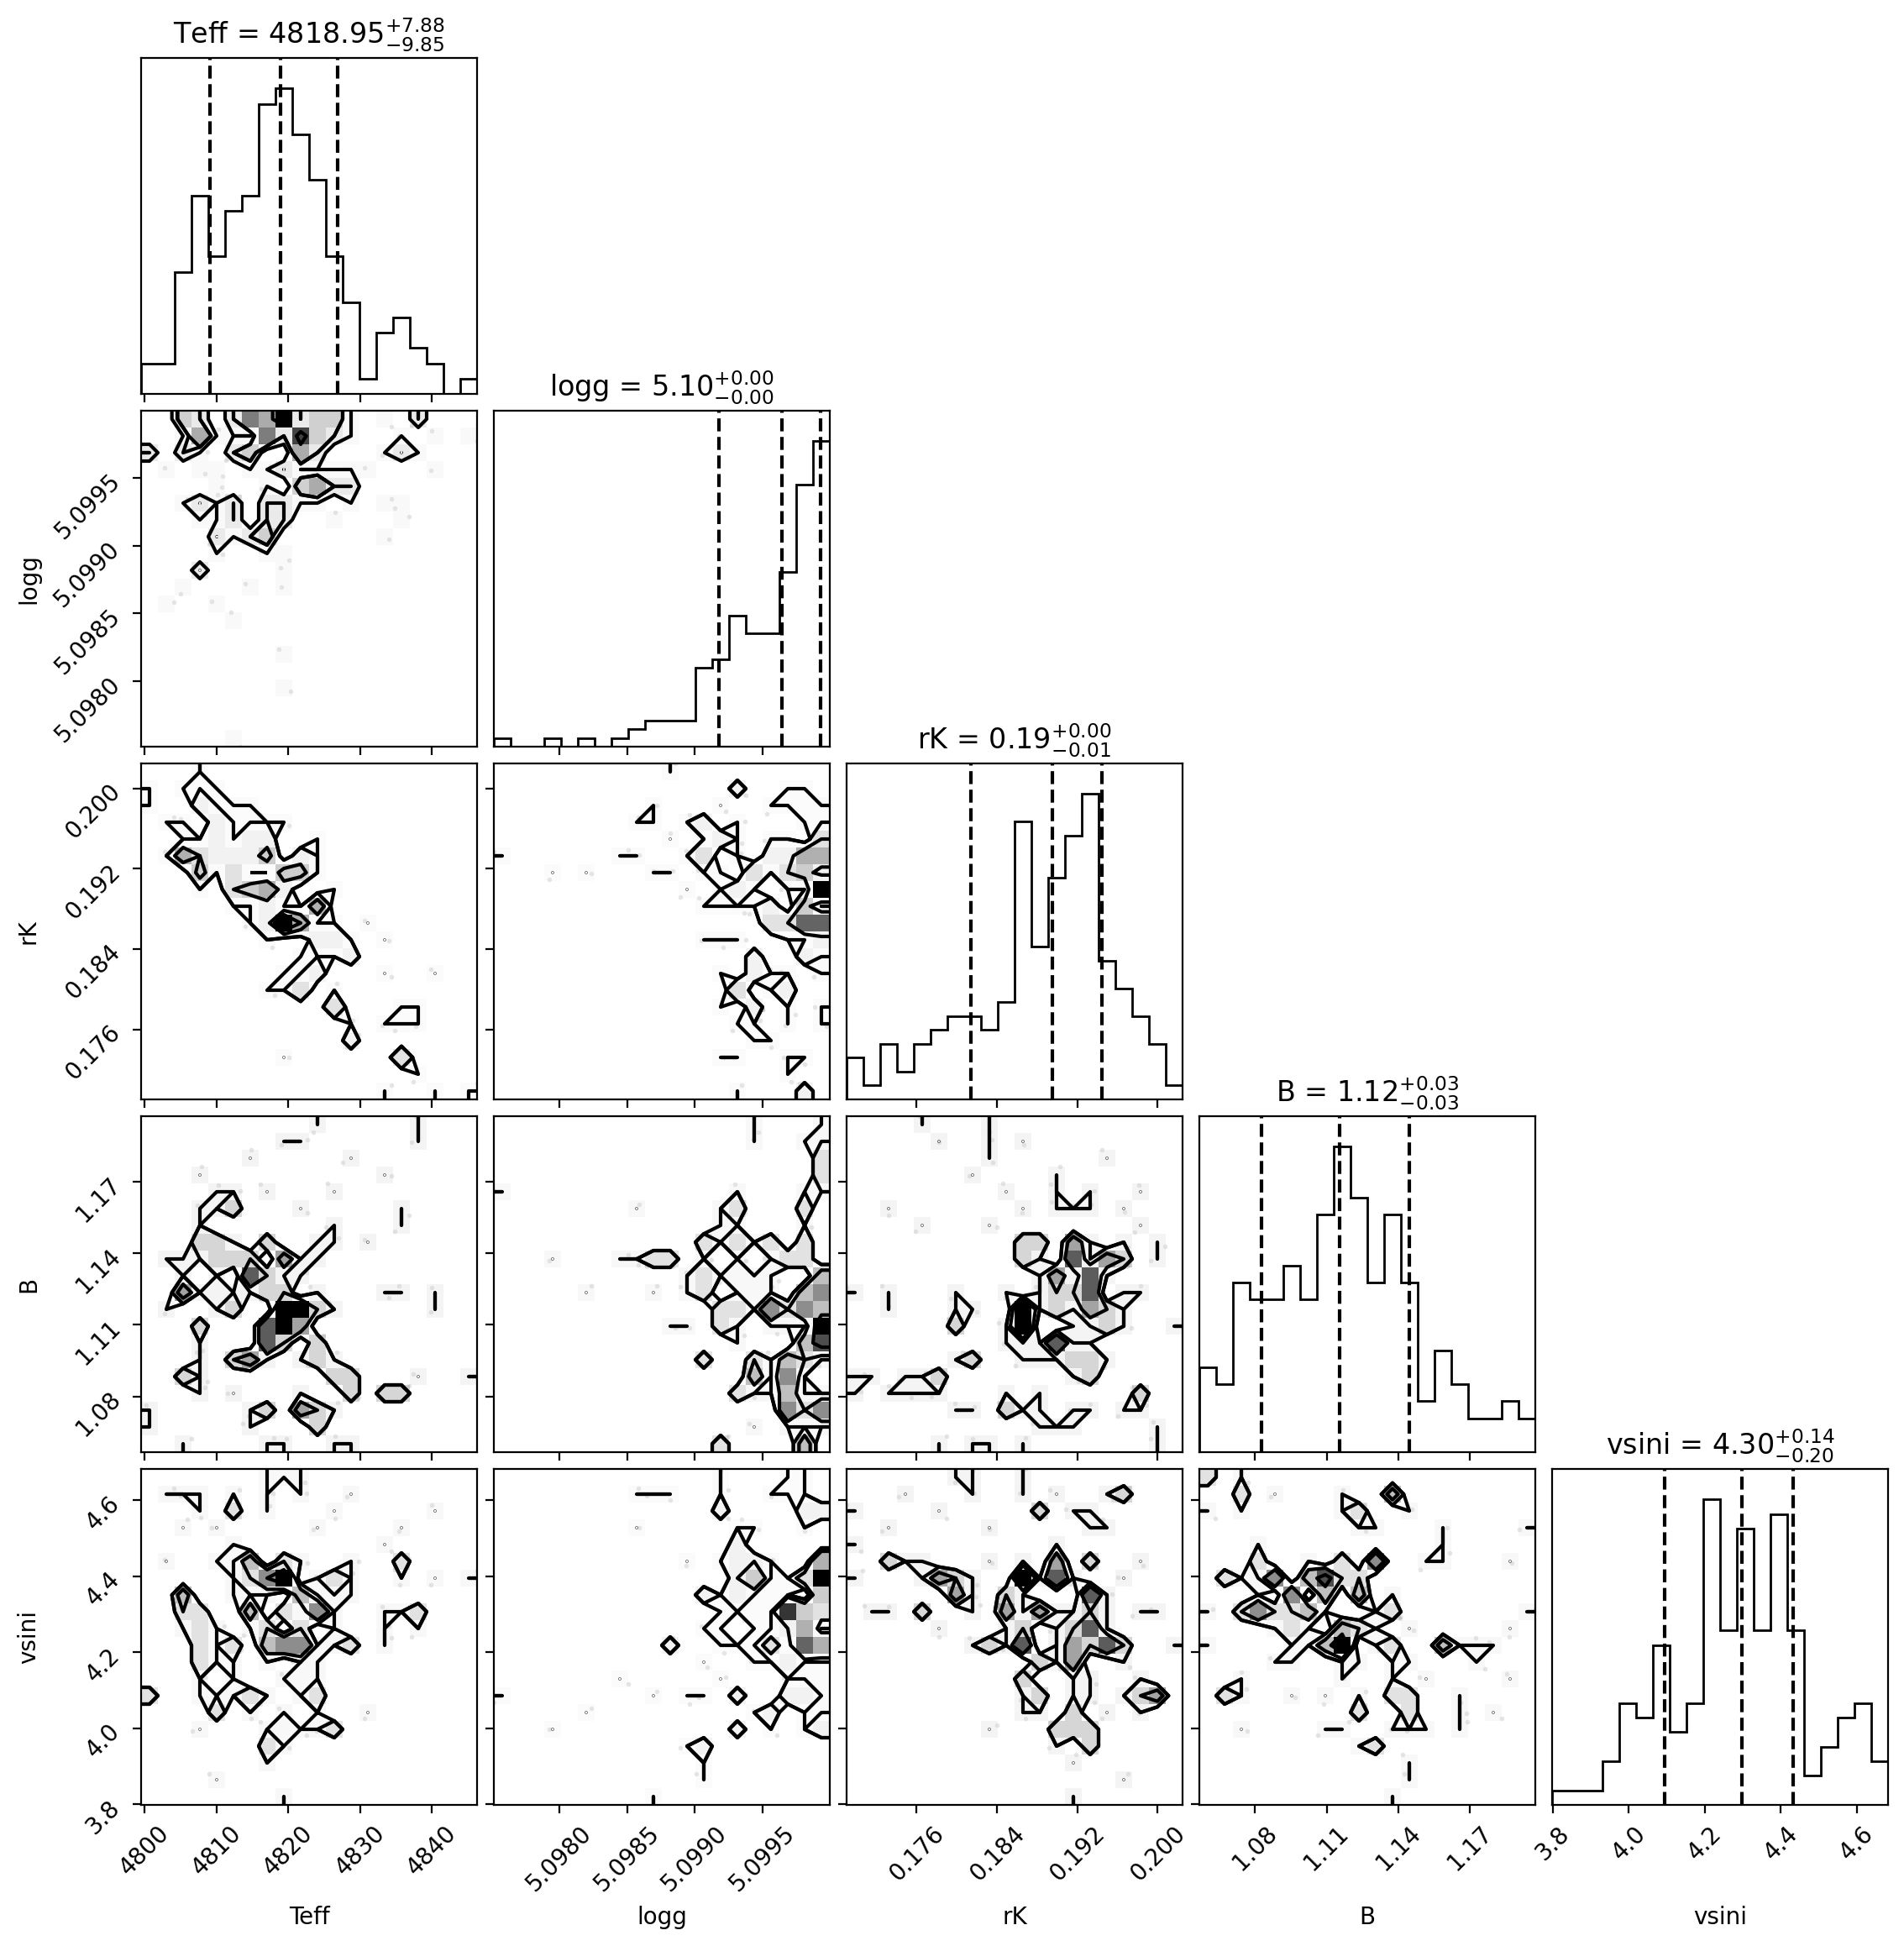

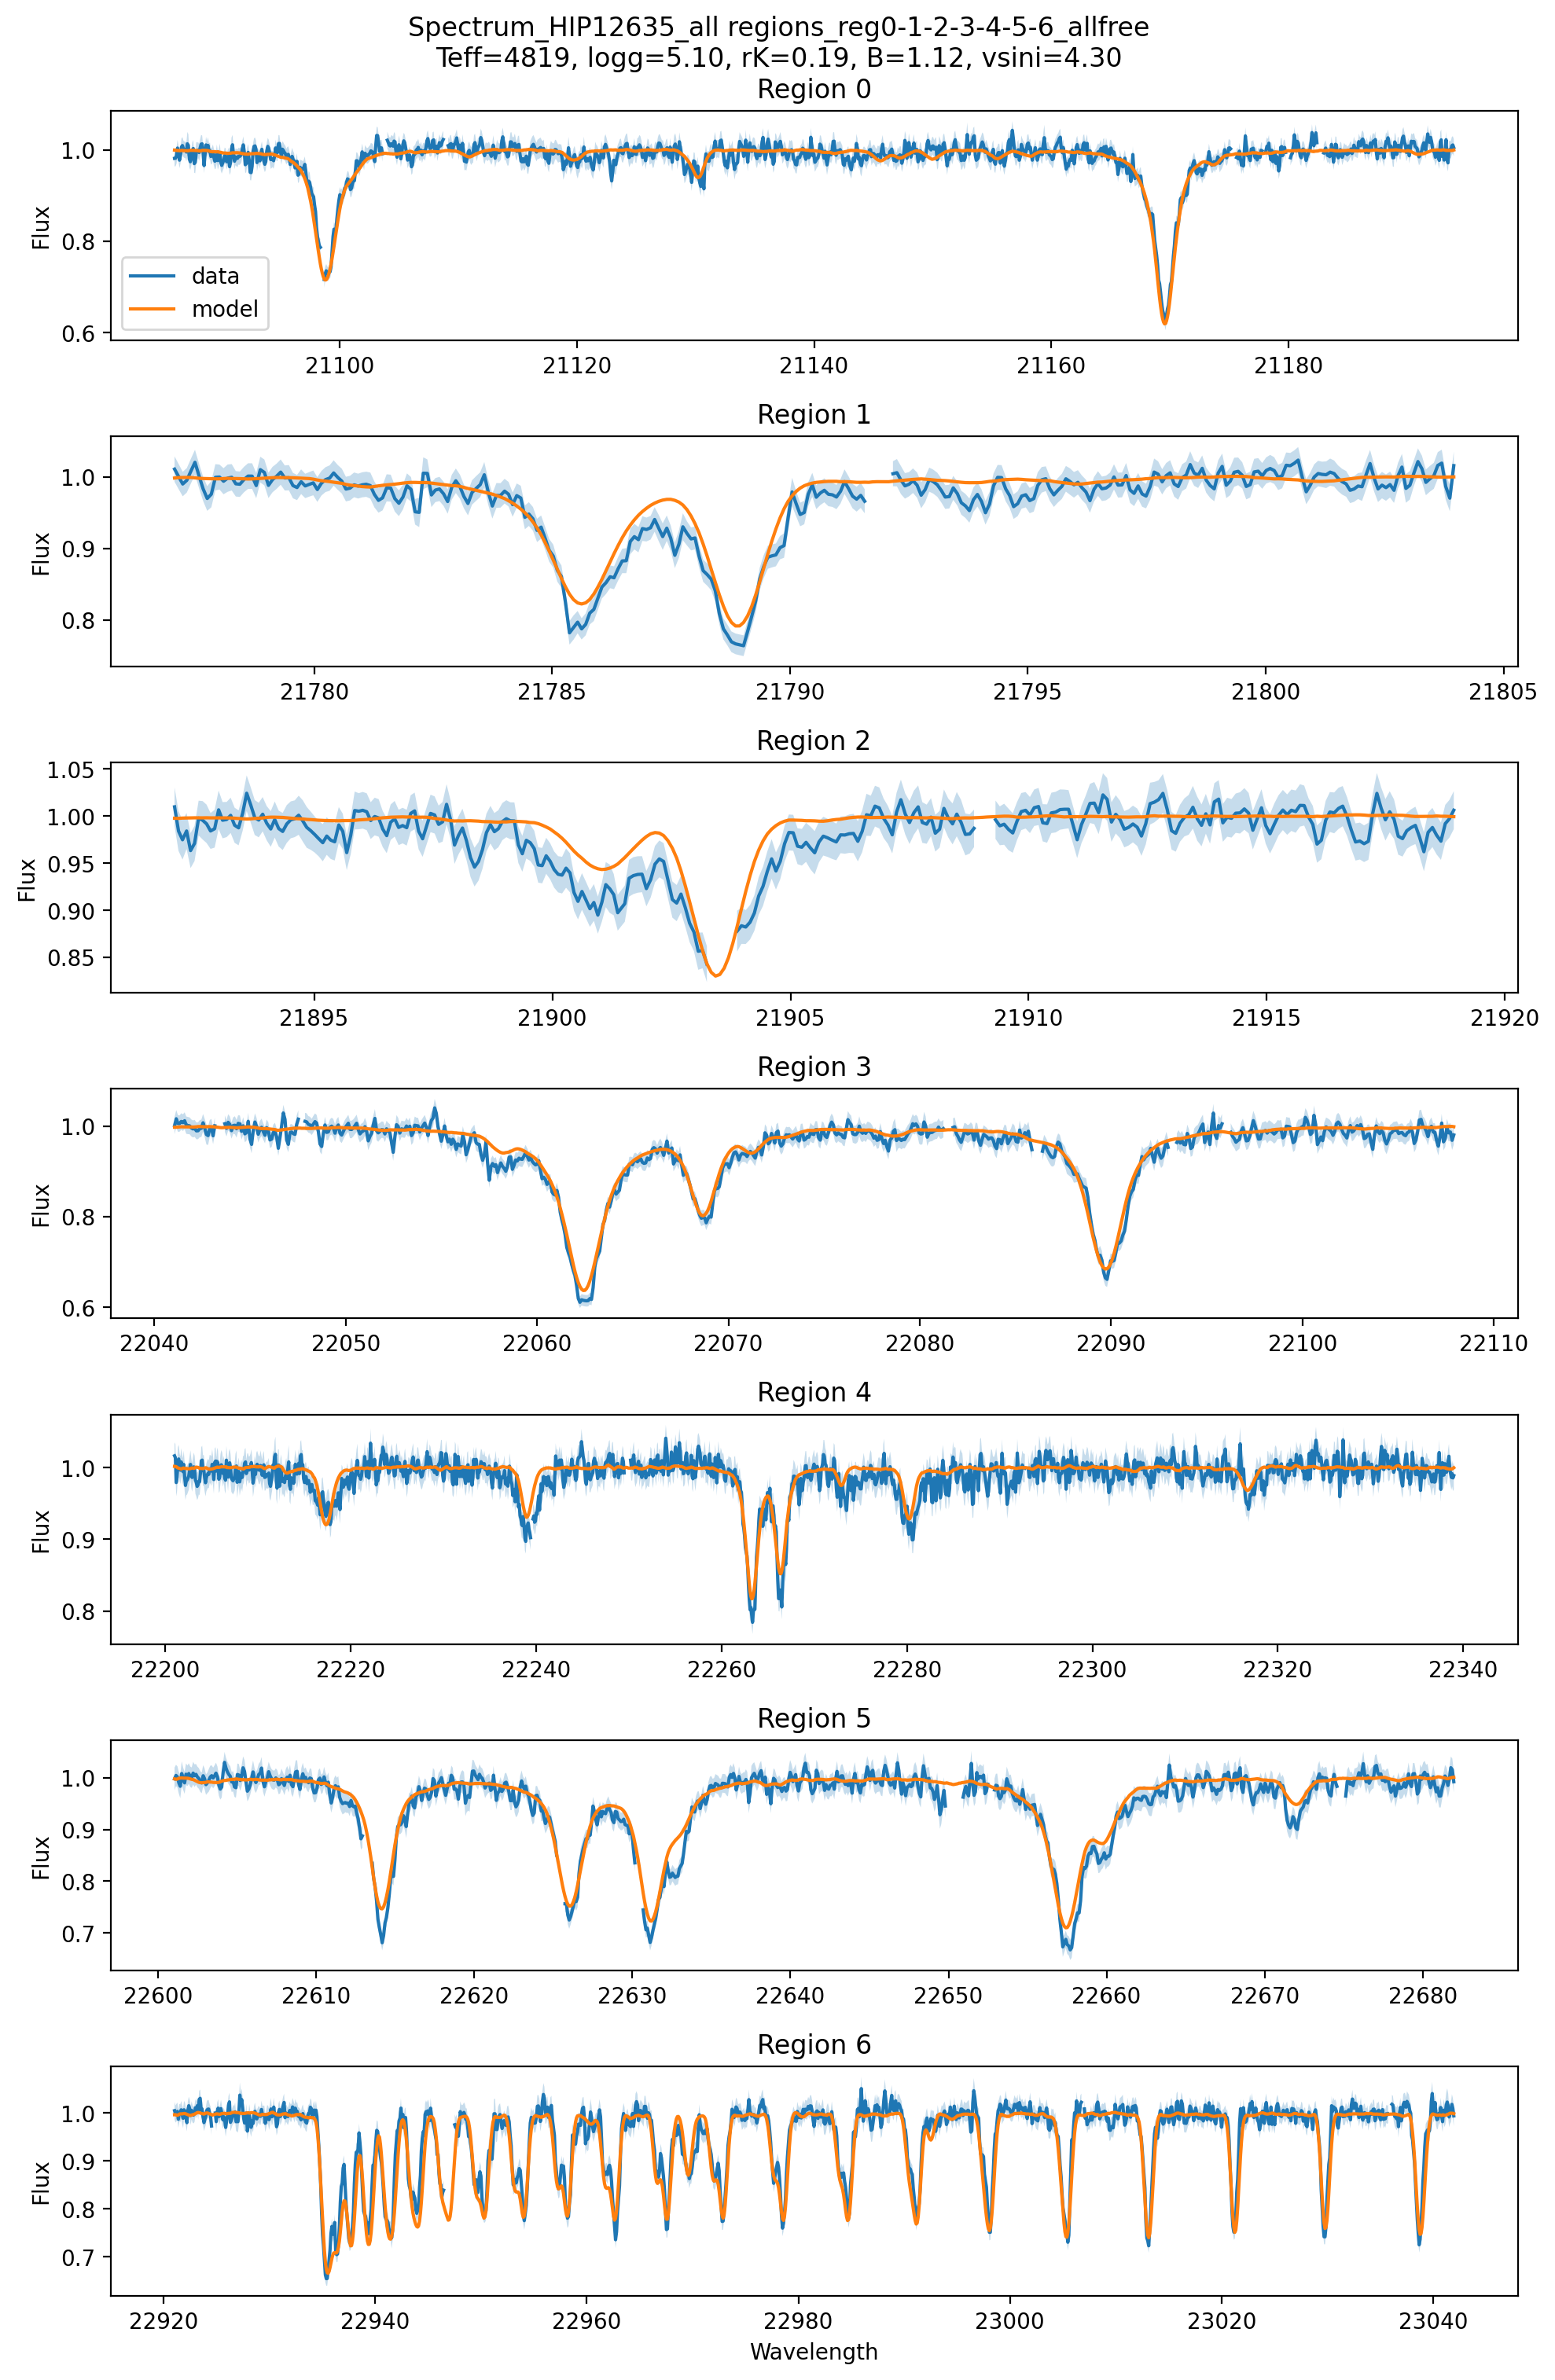

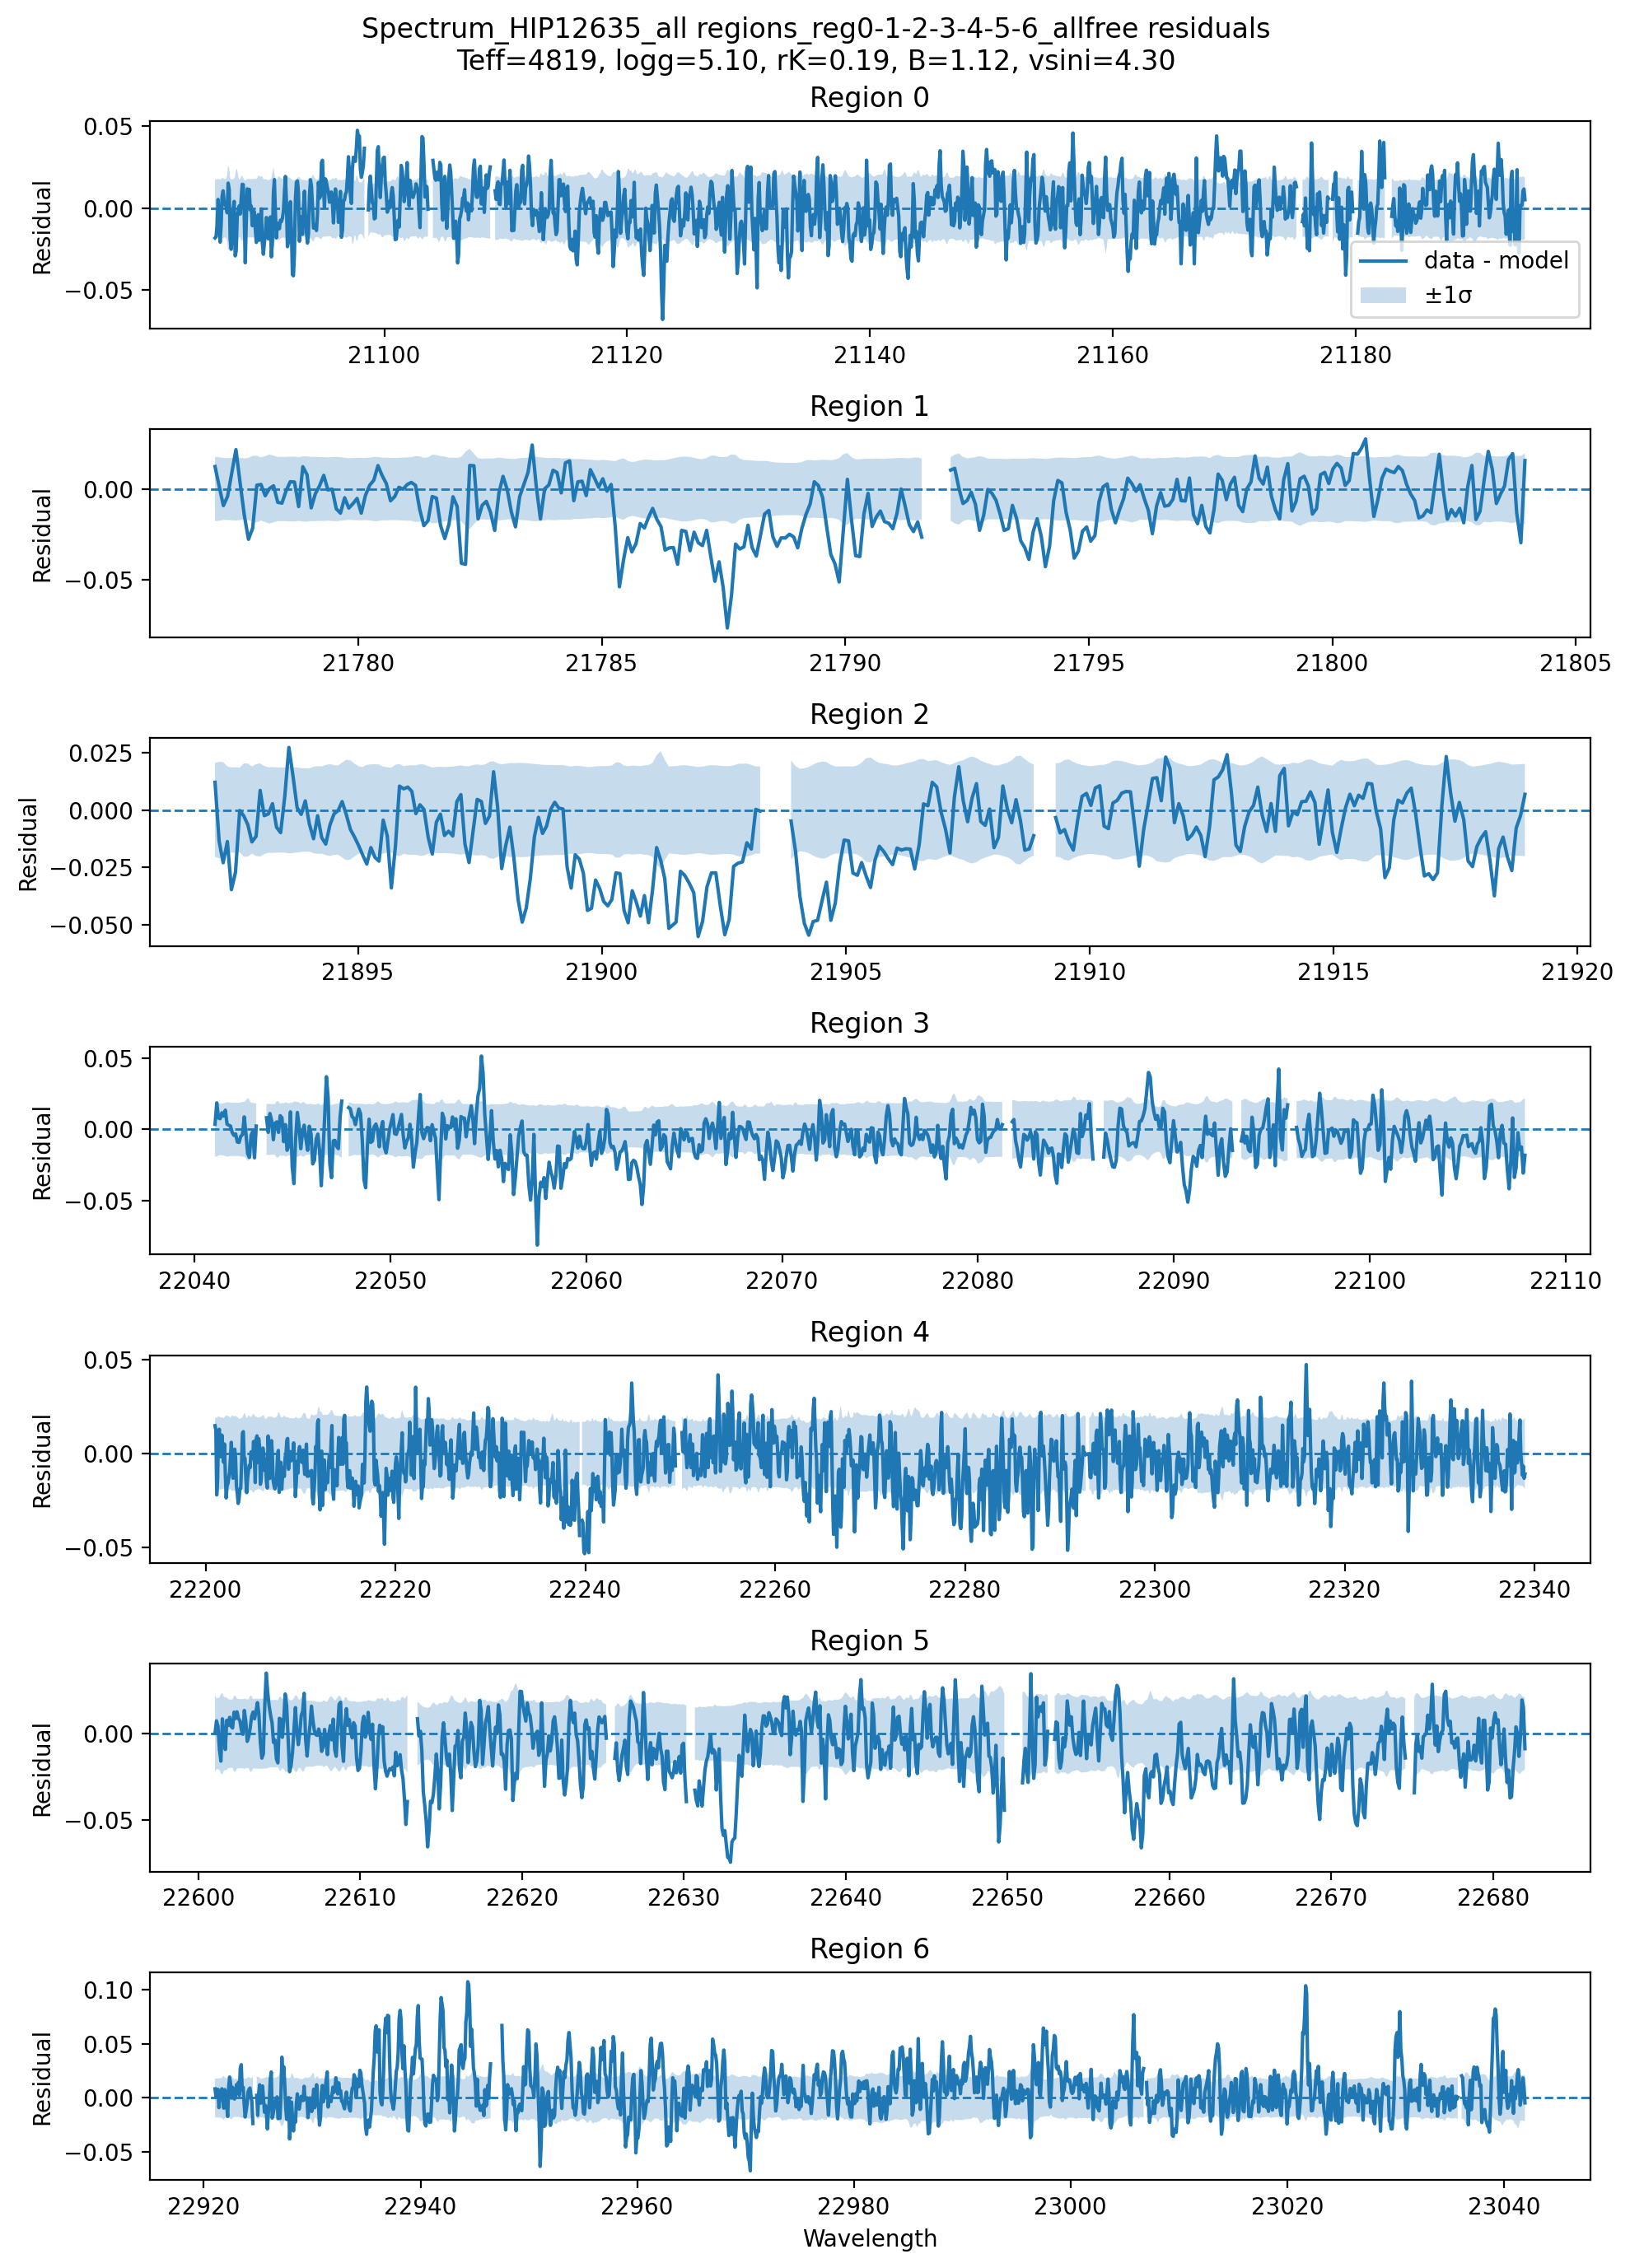

In [11]:
display(Image(out1["corner_plot"]))
display(Image(out1["bestfit_plot"]))
display(Image(out1["residual_plot"]))


In [25]:
stage2_out = run_stage_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    regions=[1, 2, 3, 4, 5],
    fixed_params= {"vsini": 7.5},#{},# {"vsini": vsini_stage1}, #vsini_stage1
    stage_label="stage 2 Lop-val high vsini ", #"stage2_fix_vsini no region 0 renorm"
    nwalkers=64,
    nsteps=2000,
    scale_discard=1000,
    scale_thin=5,
    mcmc_runs_dir="mcmc_runs",
    save_mcmc_run_file=True,
)

[Nyquist sampling] Factor applied: 1. Old SNR = 105.88610166741441
[Nyquist sampling] Factor applied: 1. New SNR = 105.88610166741441


100%|██████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [24:41<00:00,  1.35it/s]


[yerr rescaled] Factor applied: 3.721256701213234. Total scaling so far: 3.721256701213234


100%|██████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [47:38<00:00,  1.43s/it]


MCMC run file: /Users/christianflores/Documents/GitHub/moogstokes-nn/mcmc_runs/Spectrum_TWA8A_stage 2 Lop-val high vsini _reg1-2-3-4-5_fixvsini7p5_20260722_135836_mcmc_run.npz
Summary CSV: /Users/christianflores/Documents/GitHub/moogstokes-nn/mcmc_runs/mcmc_summary_flexible.csv


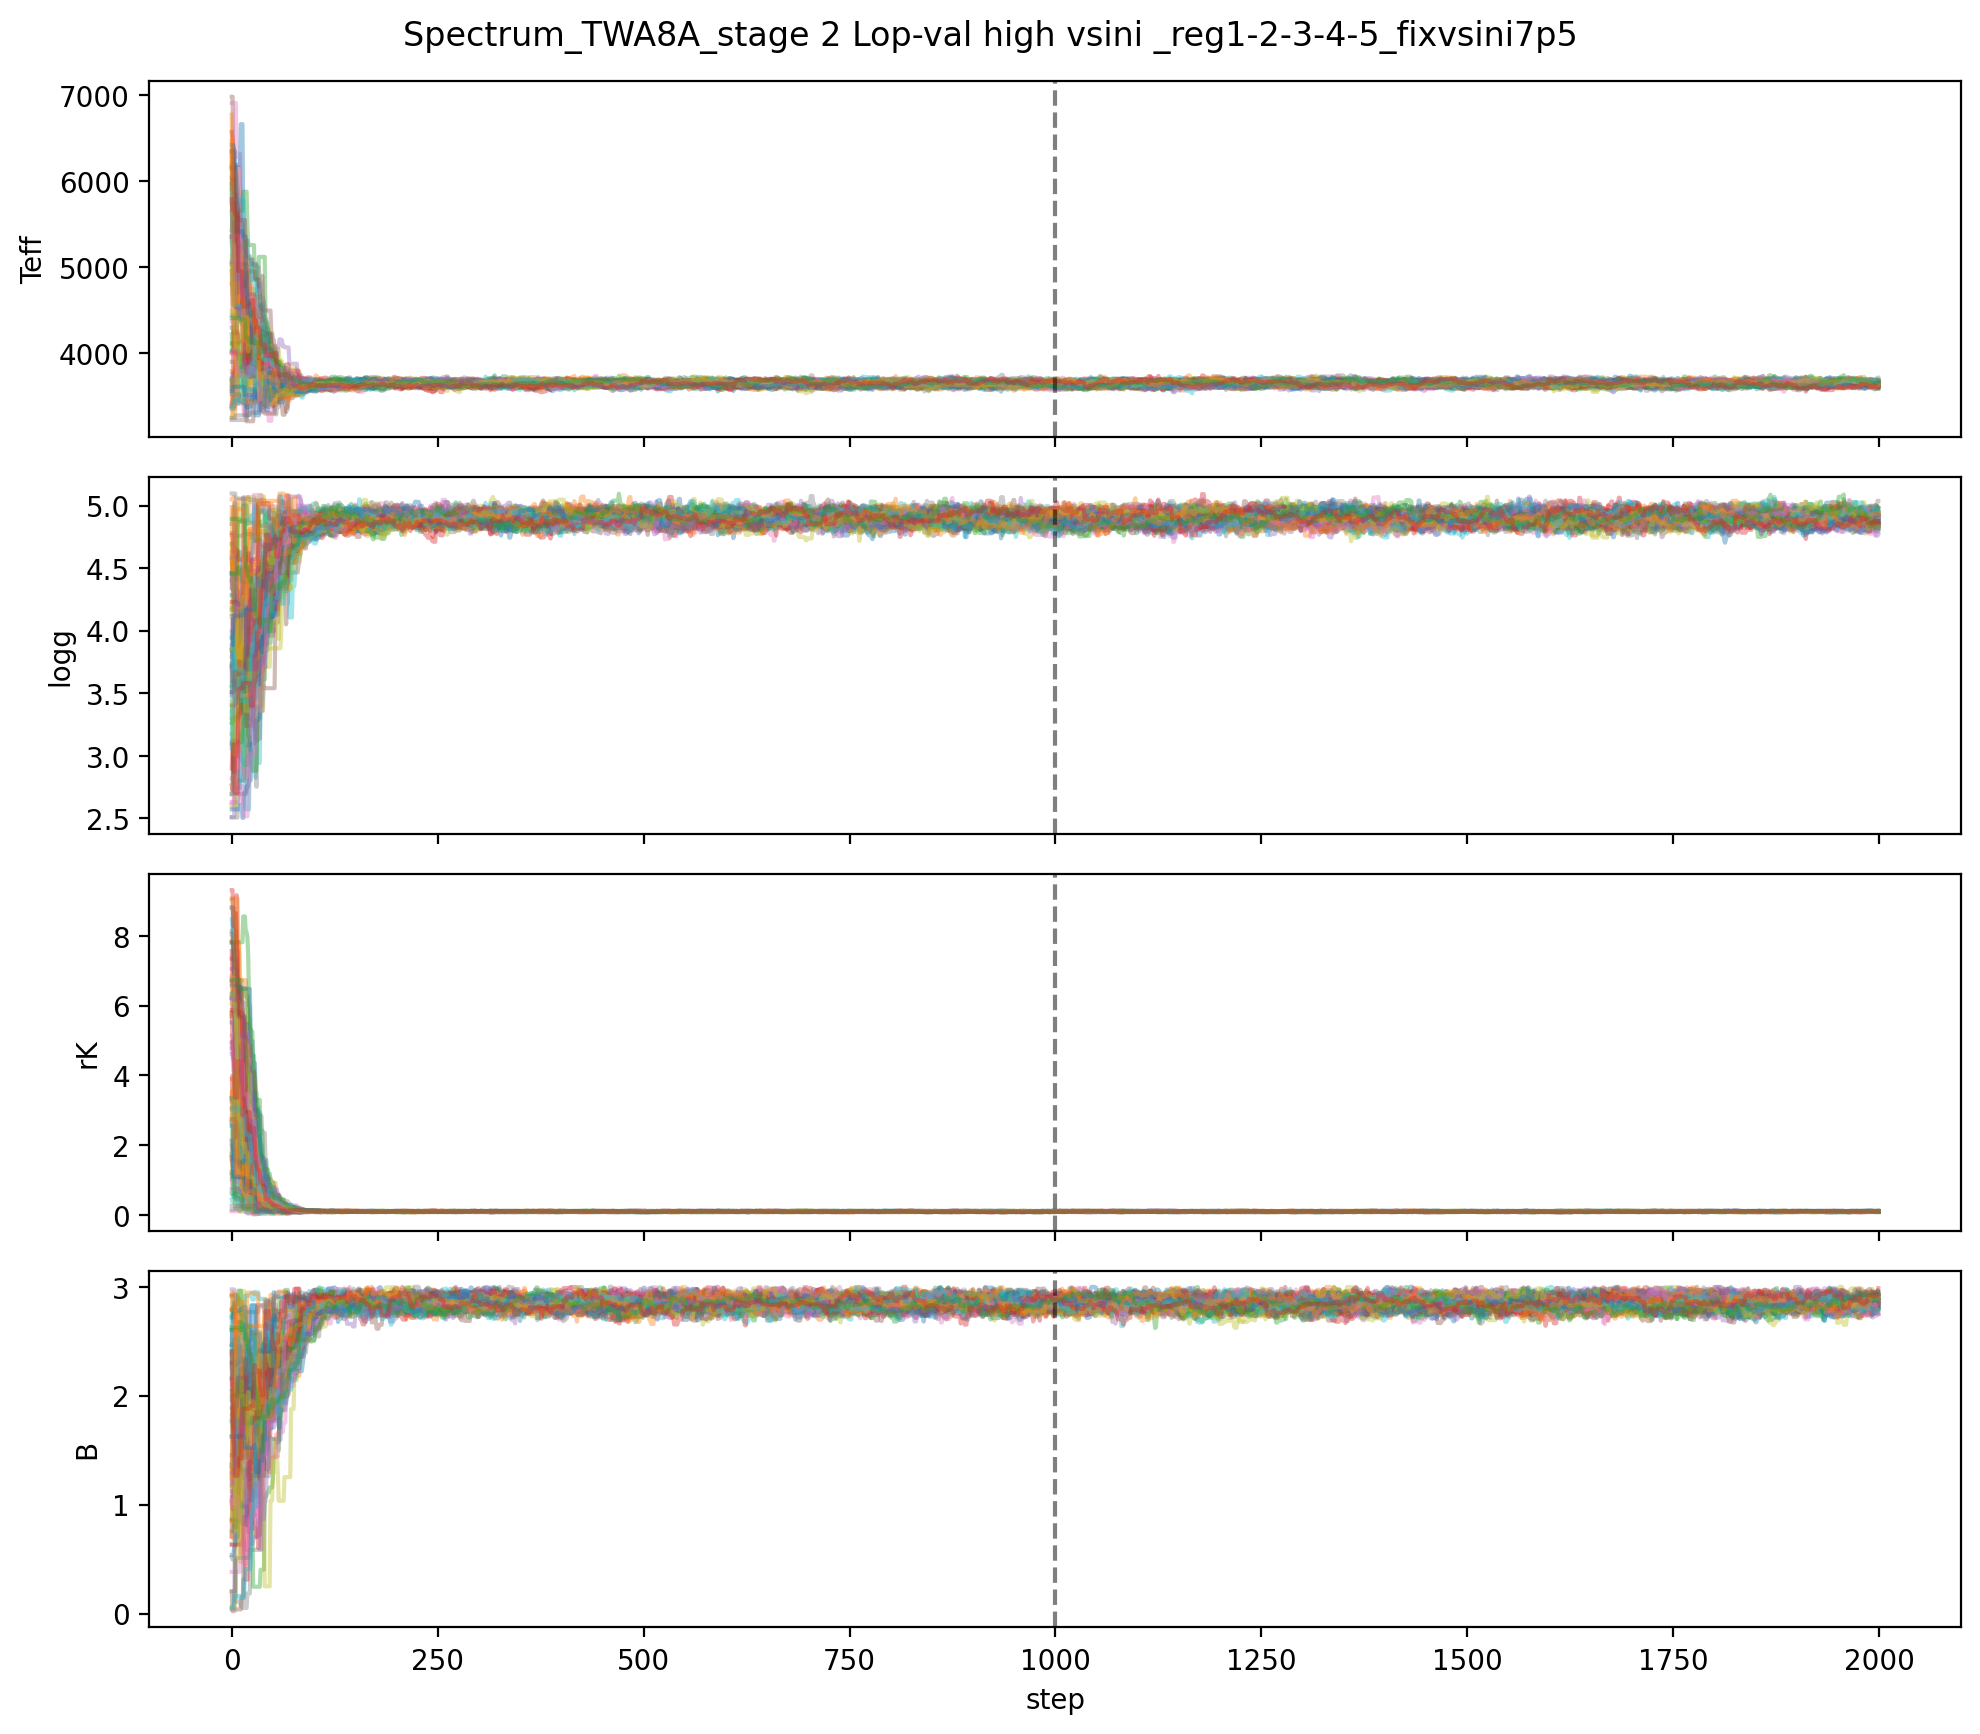

In [26]:
out2 = postprocess_stage_result(
    stage2_out,
    moognn=moognn,
    data_path=data_path,
    discard=1000,
    thin=5,
    save_fits=False,
    mcmc_runs_dir="mcmc_runs",
    figures_dir="figures",
    best_percentile=50,
    uncertainty_percentiles=(16, 84),
)

print("MCMC run file:", out2["mcmc_run_file"])
print("Summary CSV:", out2["summary_csv"])

display(Image(out2["trace_plot"]))


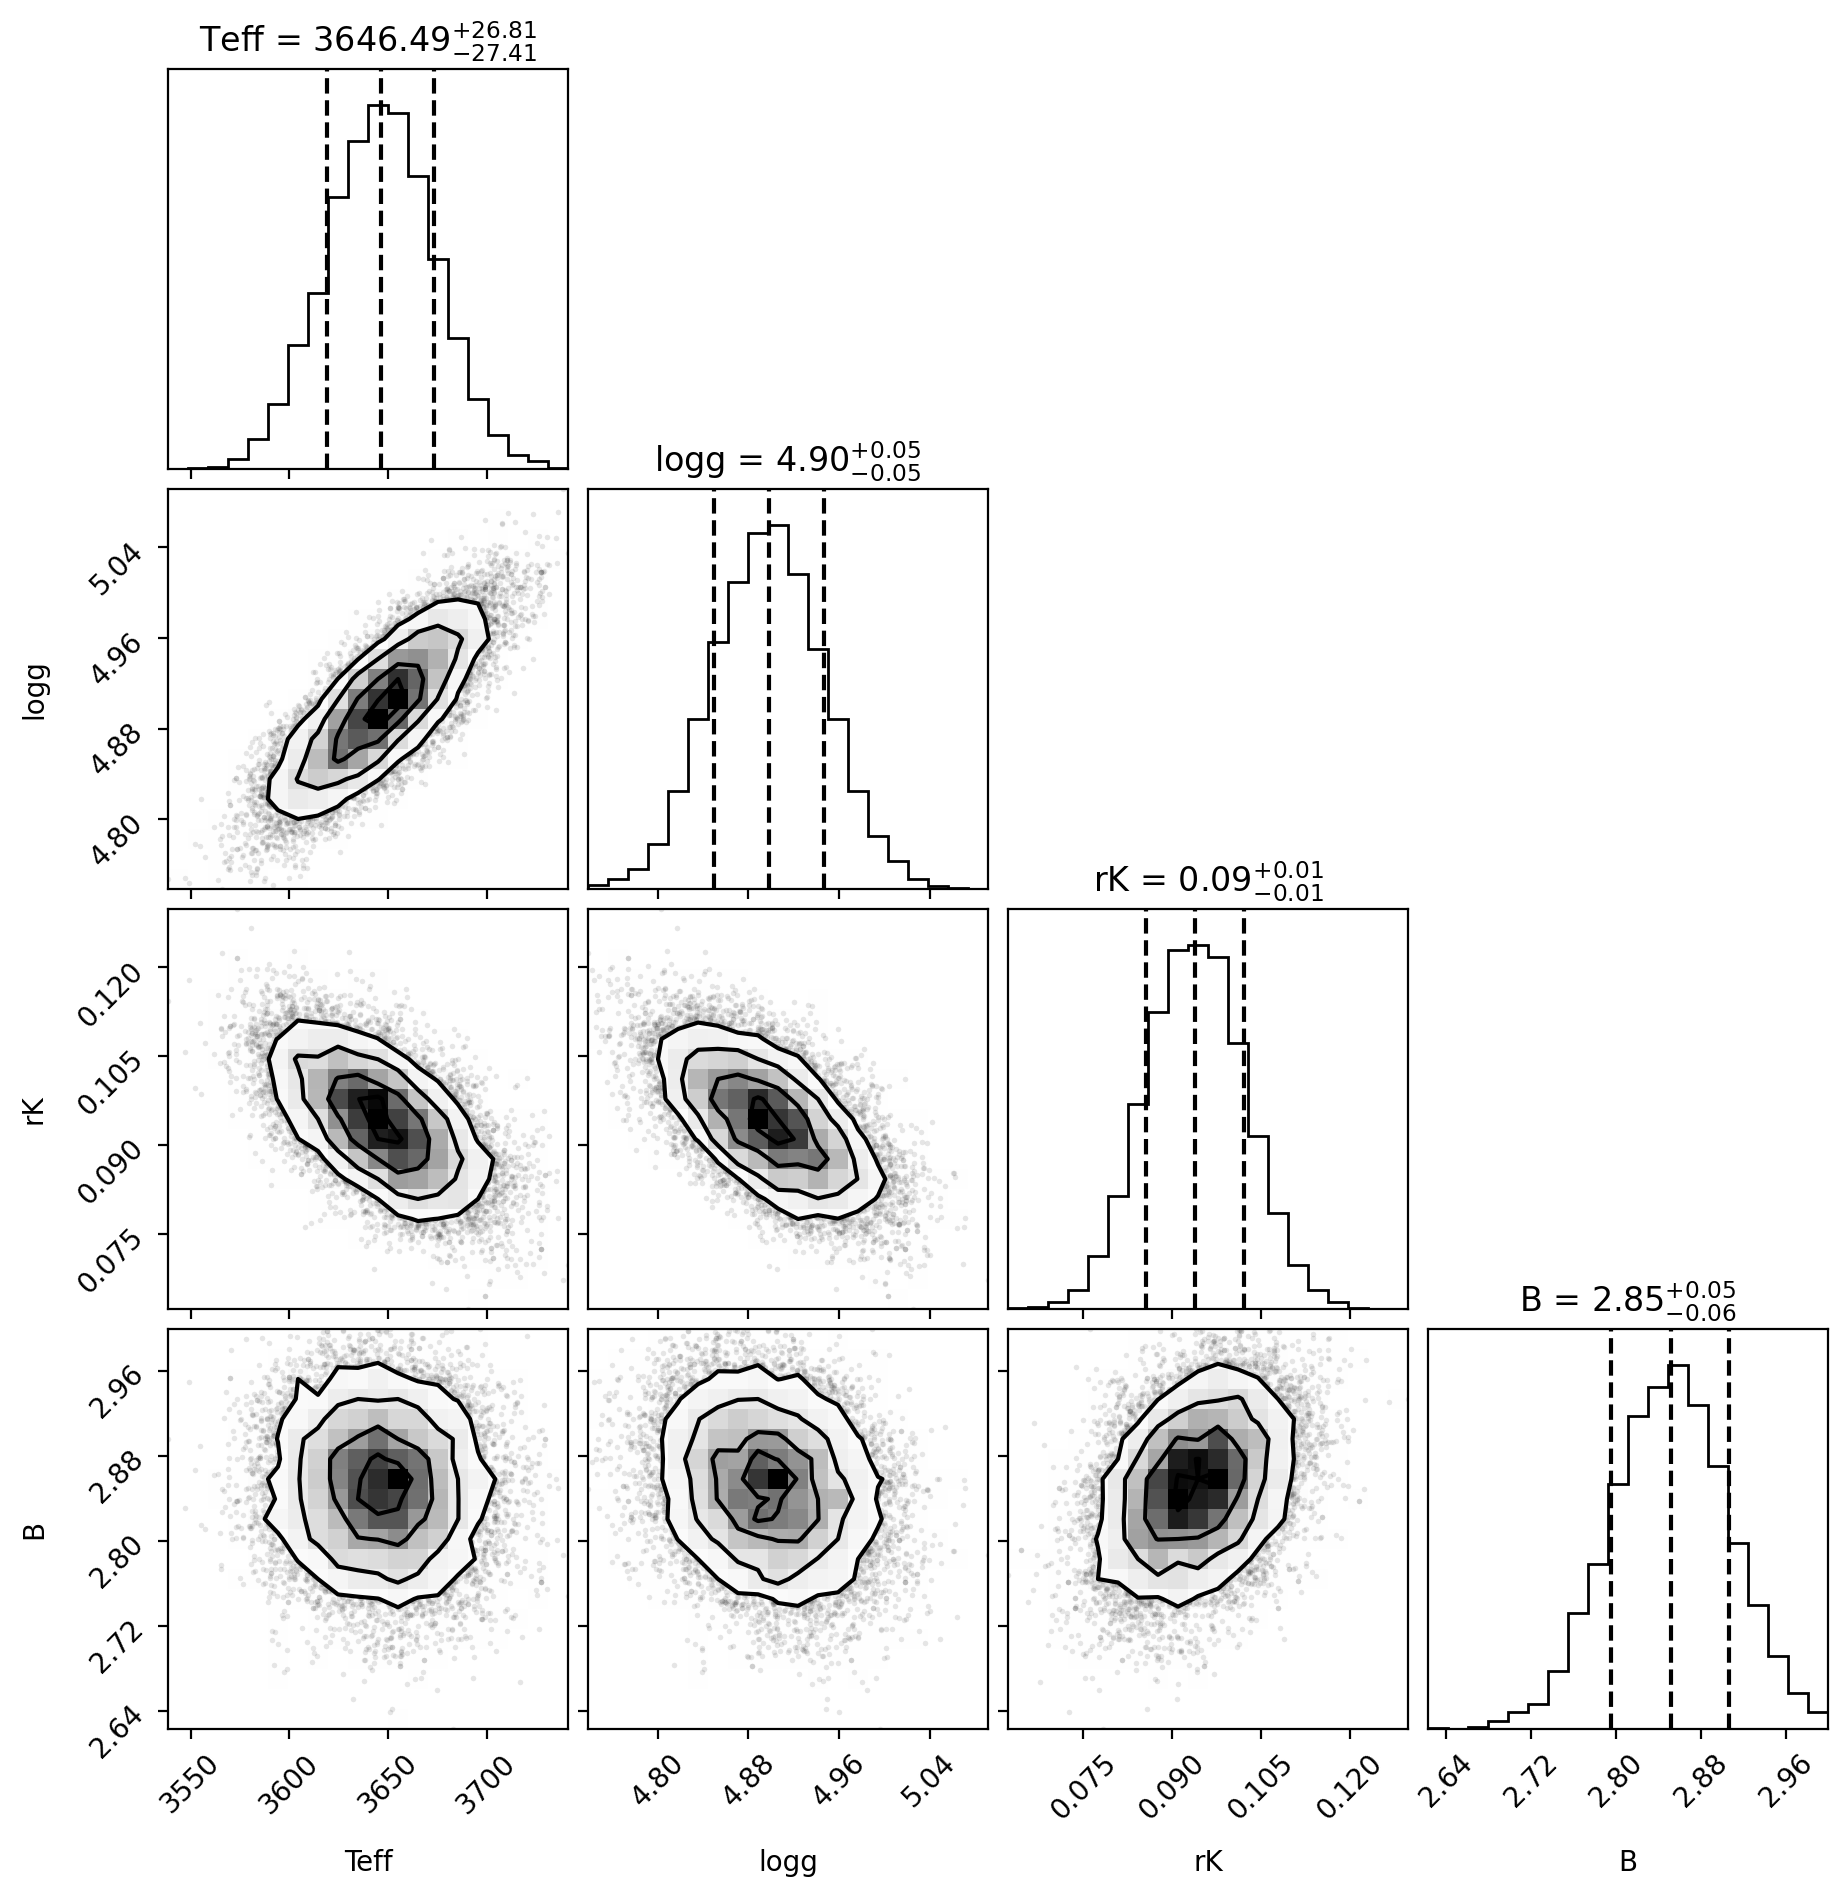

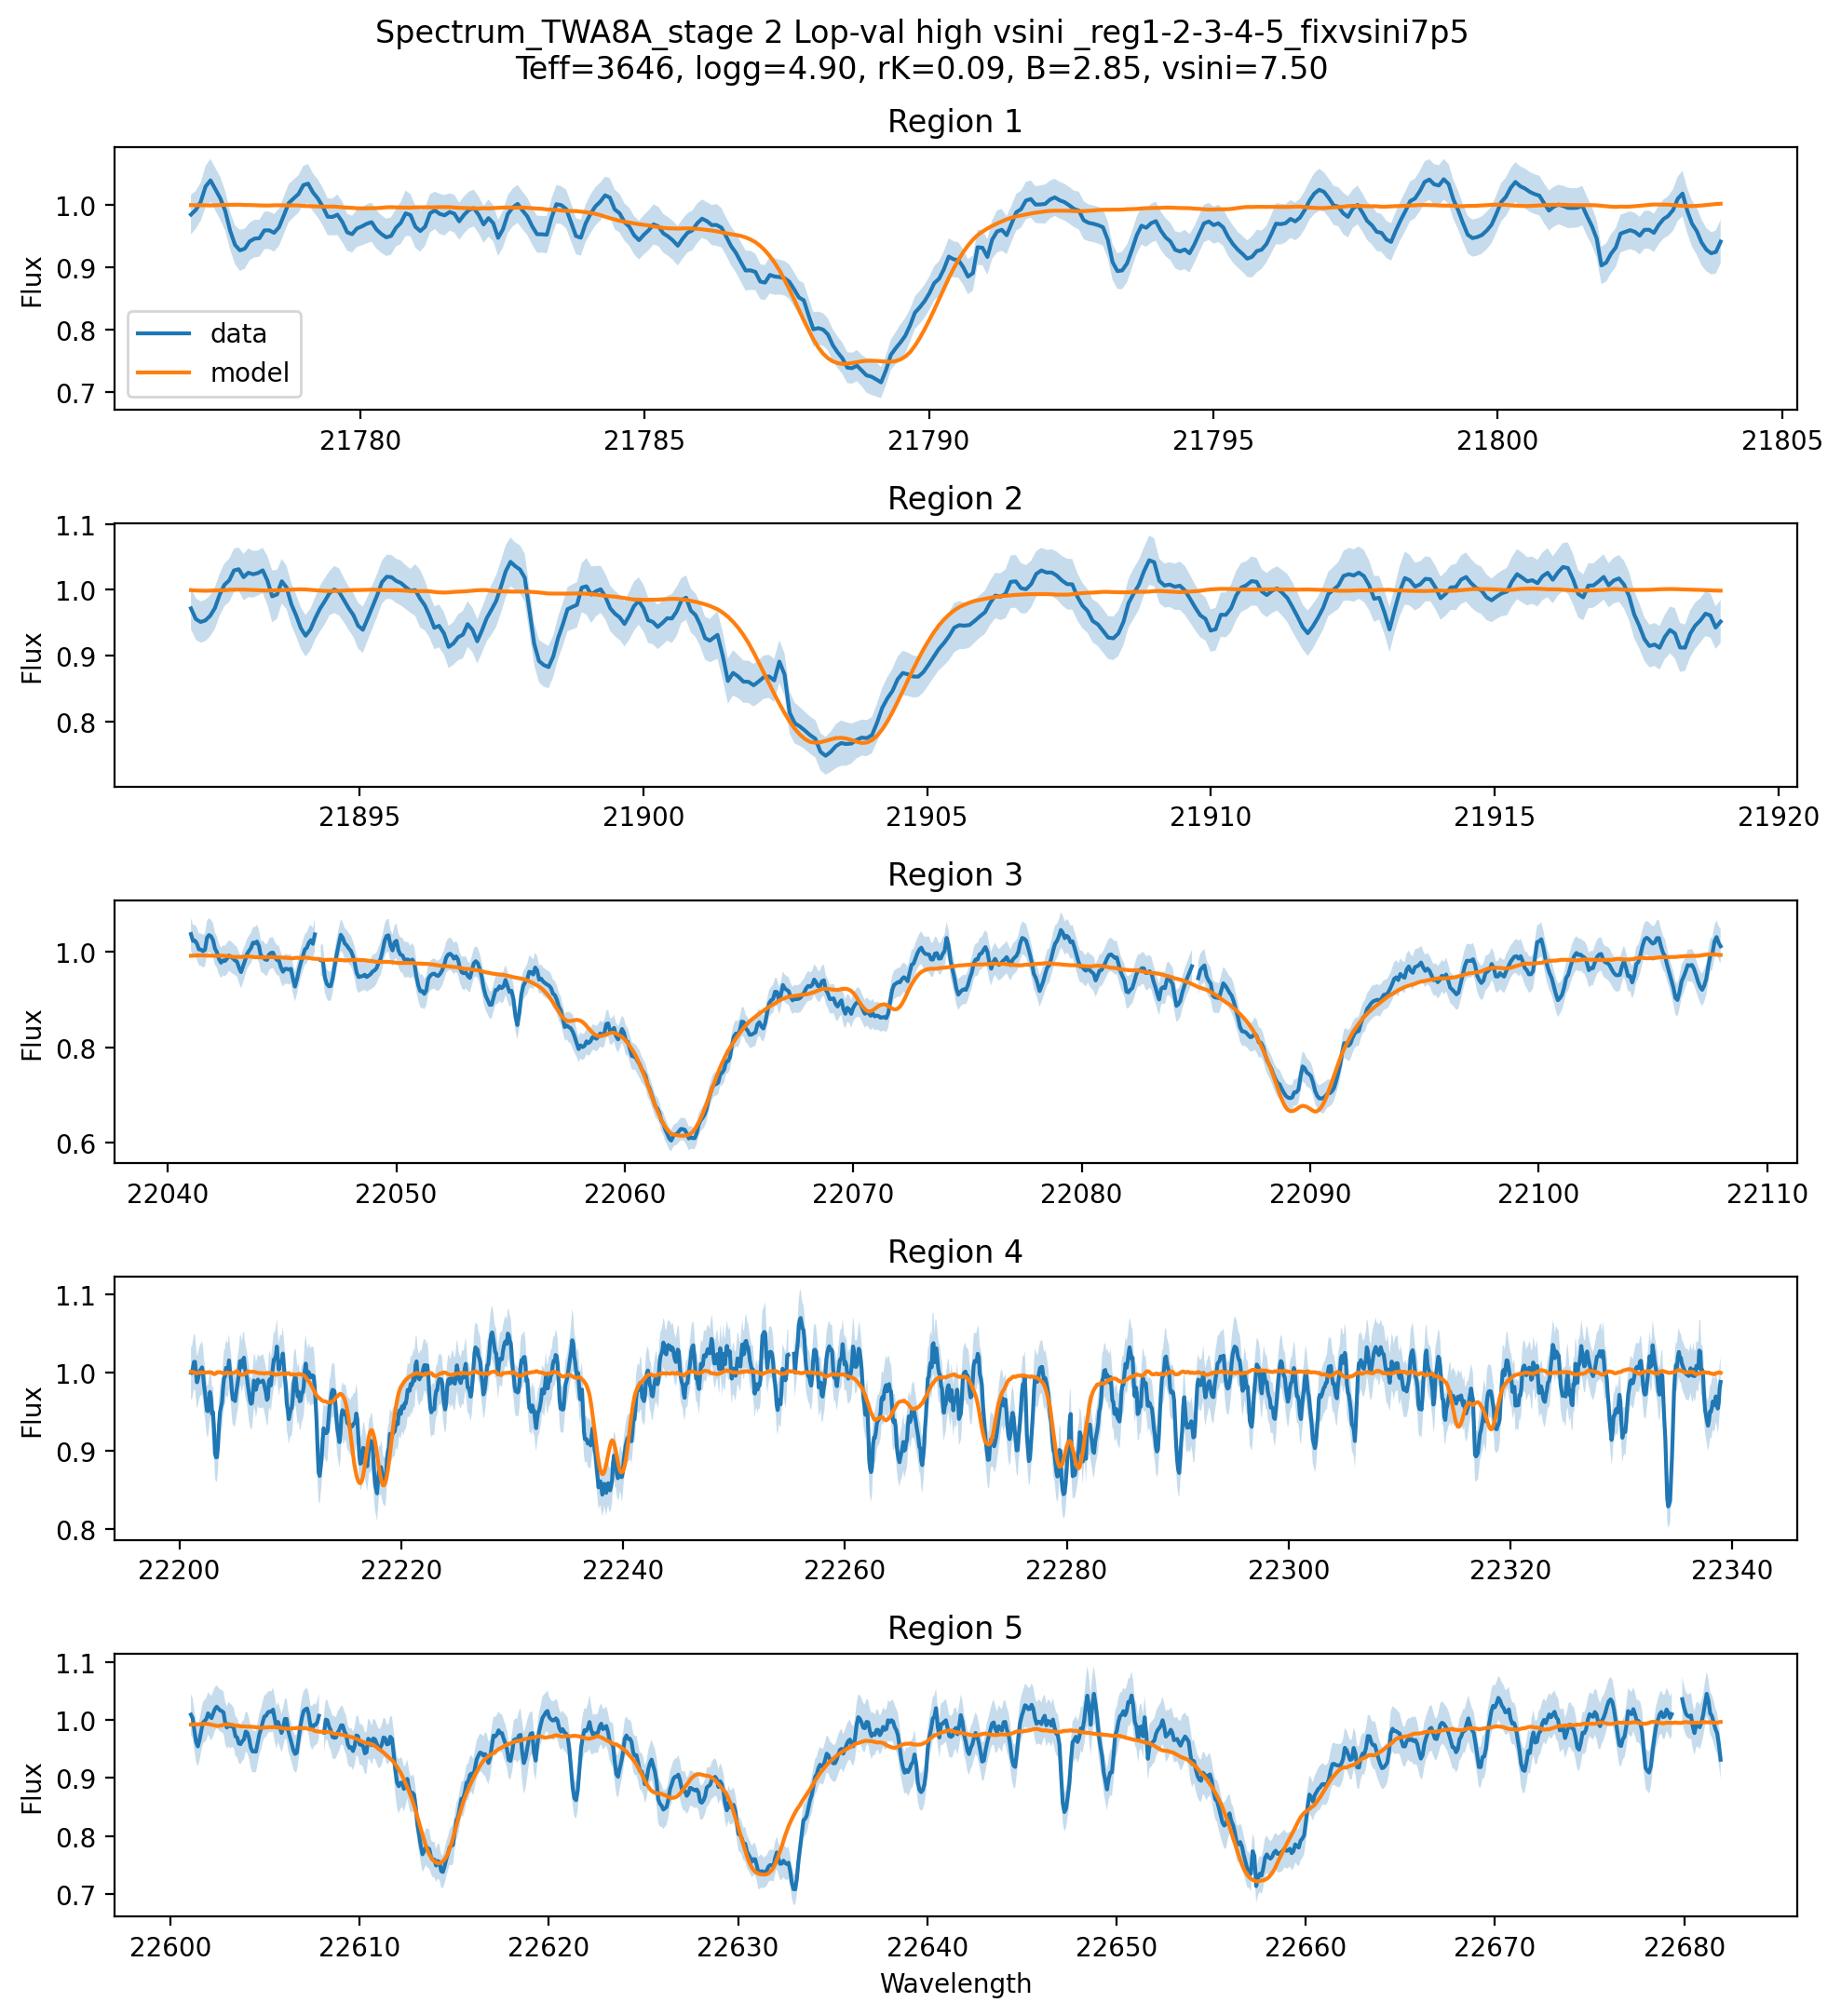

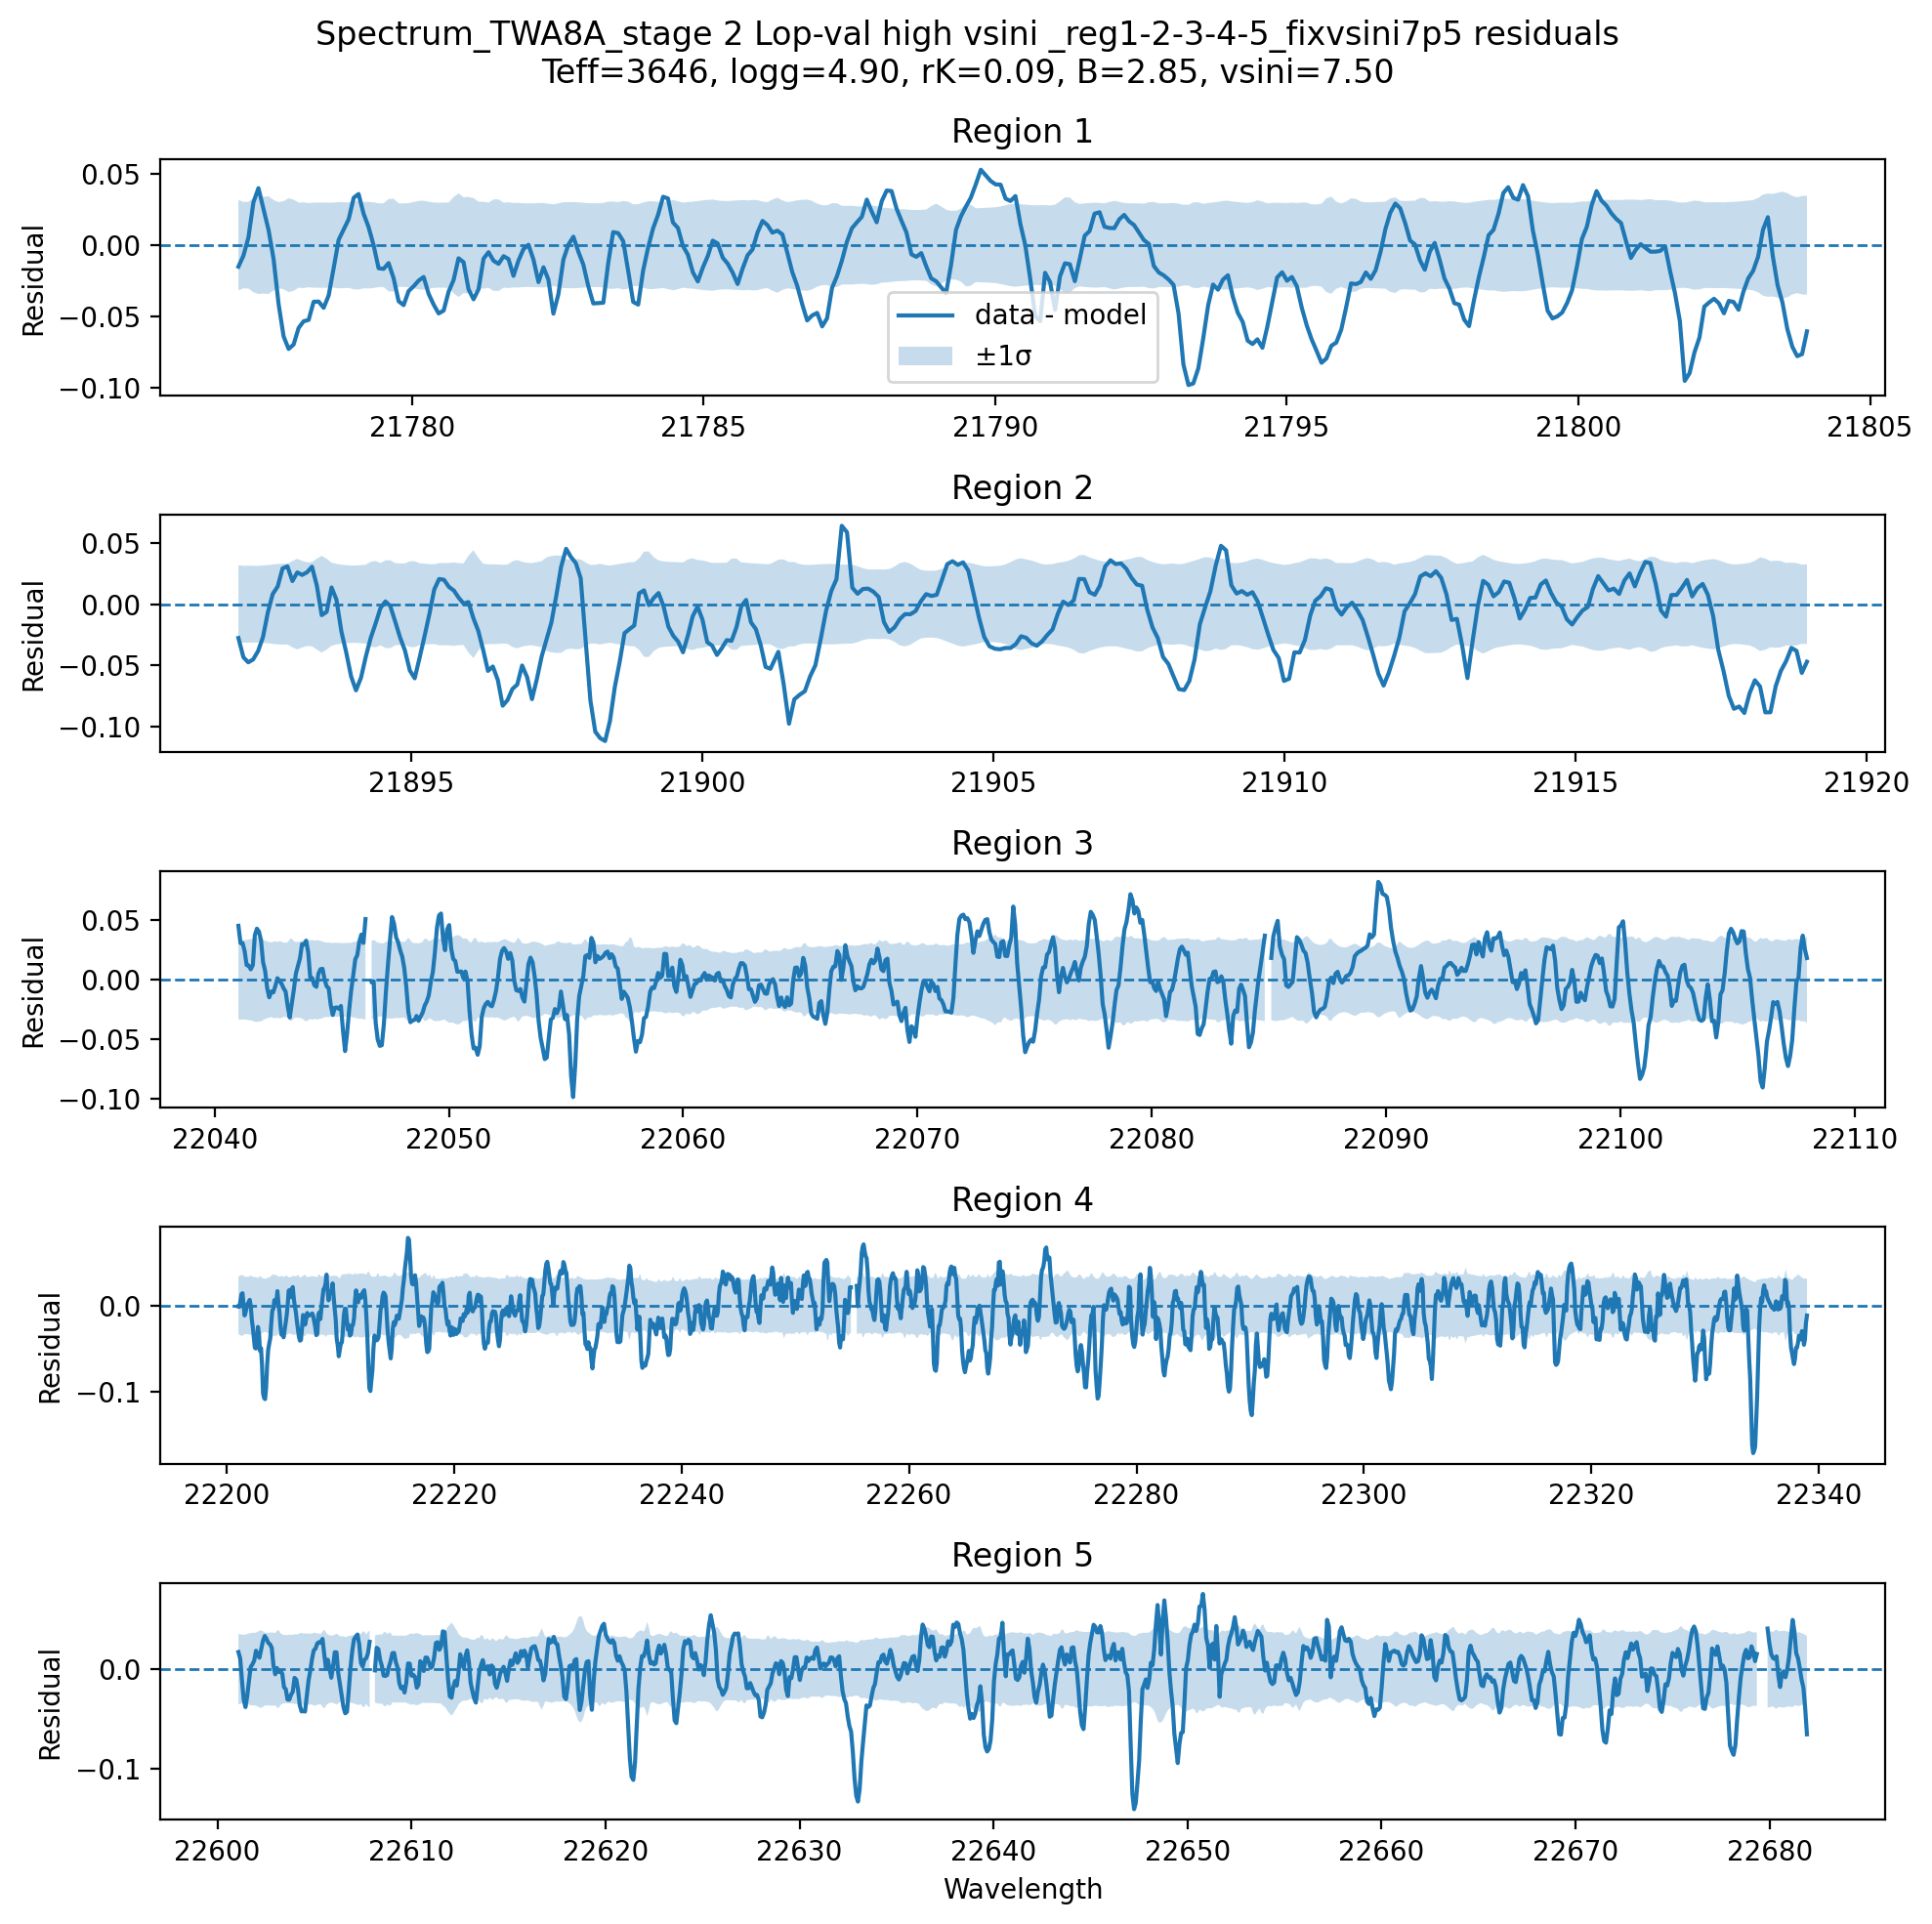

In [27]:
display(Image(out2["corner_plot"]))
display(Image(out2["bestfit_plot"]))
display(Image(out2["residual_plot"]))


In [ ]:
# Regenerate plots and parameter summaries from a saved chain without rerunning MCMC.
# Example: switch from a 68% interval to a central 3-sigma interval.
#
# out2_98 = postprocess_mcmc_run_file(
#     out2["mcmc_run_file"],
#     moognn=moognn,
#     data_path=data_path,
#     discard=300,
#     thin=5,
#     save_fits=False,
#     mcmc_runs_dir="mcmc_runs",
#     figures_dir="figures",
#     best_percentile=50,
#     uncertainty_percentiles=(0.135, 99.865),
# )
